In [1]:
using PyPlot
using JLD2
using Statistics
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful
using Interpolations
using LsqFit

In [2]:
pathdir_stripe_90 = "Y:/StructuralPhaseTransition/2026/02/11/0001" # Stripes 90°

N = 30
λ = 421e-9
γ = 32.7e6 # In Hz
Γ = 2.02e8 # In Hz

ω0 = 2π*ustrip(c_0)/λ

Isat = Γ*ω0^2 / (12*π*ustrip(c_0)^2) # In photon/m^2/atom

factor_ellipse = 2
size_pxl = 0.1966e-6; # New pxl size since 2025/12/31

### Load experimental data

In [3]:
# Stripe 90
@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" Amplitude_laser τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds
@load "Saved_exp_data/Intensity_integrated_all_img_stripes_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" Iatoms_img Ibkg_img Idark_img Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms
@load "Saved_exp_data/Stripes_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" centers_stripes_ds major_axis_stripes_ds minor_axis_stripes_ds nbr_stripes_ds
Ntot = 185491; # Total atom nbr

### Fit the experimental saturation parameter

In [4]:
I_elec_measured = [0.1:0.1:1;]
P_measured = [0.004, 0.035, 0.15, 0.43, 0.9, 1.5, 2.1, 2.6, 3, 3.4] * 1e-3
w0 = 300.0750022524122e-6 # Fitted waist
sat_measured = 2 .* P_measured ./ (π*w0^2 * Isat * ustrip(ħ * ω0))
interp_linear = linear_interpolation(I_elec_measured, sat_measured);

In [5]:
linear(x, p) = p[1] .* x
p0 = [2.]
fit = curve_fit(linear, reshape(mean(Ibkg_img/Isat, dims=2), length(unique(Amplitude_laser))), interp_linear(unique(Amplitude_laser)), p0)
factor_sat = fit.param[1];

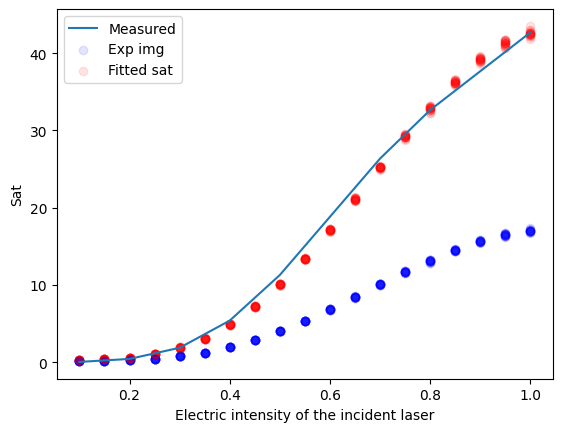

In [6]:
close("all")
fig = subplot()

plot(I_elec_measured, sat_measured, label="Measured")

for i = 1:size(Ibkg_img)[1]
    for j = 1:size(Ibkg_img)[2]
        if Ibkg_img[i, j] > 0
            scatter(Amplitude_laser[(i-1)*size(Ibkg_img)[2]+j], Ibkg_img[i, j]/Isat, color="b", alpha=0.1)
            scatter(Amplitude_laser[(i-1)*size(Ibkg_img)[2]+j], (Ibkg_img[i, j]/Isat) * factor_sat, color="r", alpha=0.1)
        end
    end
end
legend(["Measured", "Exp img", "Fitted sat"])
xlabel("Electric intensity of the incident laser")
ylabel("Sat")
# pygui(true); show()
pygui(false);

### Plot as a function of Sat measured from the images bkg

In [7]:
# Recover mean stripe surface
major_axis_list, minor_axis_list = [], []

for i = 1:size(Iatoms_img)[1]
    for j = 1:size(Iatoms_img)[2]
        if nbr_stripes_ds[i, j] > 0
            for k = 1:Int(nbr_stripes_ds[i, j])
                push!(major_axis_list, major_axis_stripes_ds[i][j][k])
                push!(minor_axis_list, minor_axis_stripes_ds[i][j][k])
            end
        end
    end
end

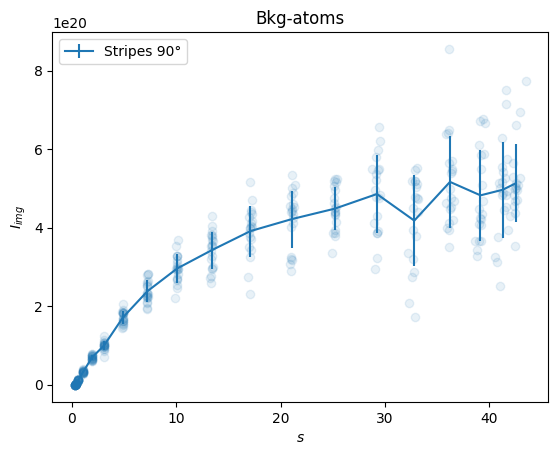

In [9]:
close("all")
fig = subplots()
title("Bkg-atoms")


# Stripes 90°
line_stripe_90, = errorbar(factor_sat * Mean_bkg/Isat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Stripes 90°")

for i = 1:size(Iatoms_img)[1]
    for j = 1:size(Iatoms_img)[2]
        scatter(factor_sat * Ibkg_img[i, j]/Isat, Ibkg_img[i, j]-Iatoms_img[i, j], color=line_stripe_90.get_color(), alpha = 0.1)
    end
end


# # Simulations
factor_sim_data = (1-0.16) # Amount of light that will not enter in the camera
@load "Solutions_sim/Itot_N_10_Sat_0.1to35.0_n0_55.23_decay_rate_up_down.jdl2" sat sat_computed n_list Itot_stripe I_SE_SR_SS_stripe I_SR_SR_SS_stripe nbr_error_N
S_img = size(Imgs_atoms_crop_ds)[1]*size(Imgs_atoms_crop_ds)[2]*size_pxl^2
S_stripe = π * 7.630504388680256e-6 * 1.5864096721914764e-6
S_stripe_data = π*mean(major_axis_list)*mean(minor_axis_list)*(size_pxl/factor_ellipse)^2

# plot(sat_computed, factor_sim_data * Itot_stripe * Ntot / (N*length(n_list)*S_stripe*mean(nbr_stripes_ds[nbr_stripes_ds.>0])), label="Simulations, surface stripe fit")
# plot(sat_computed, factor_sim_data * Itot_stripe * Ntot / (N*length(n_list)*S_img*mean(nbr_stripes_ds[nbr_stripes_ds.>0])), label="Simulations, surface camera")
# plot(sat_computed, factor_sim_data * Itot_stripe * Ntot / (N*length(n_list)*S_stripe_data*mean(nbr_stripes_ds[nbr_stripes_ds.>0])), label="Simulations, surface stripe data")

# for i = 1:size(I_sim)[1]
#     for j = 1:size(I_sim)[2]
#         scatter(factor_sat * Ibkg_stripe_90[i+idx_lb-1, j]/Isat, I_sim[i, j], color=line_sim.get_color(), alpha = 0.1)
#     end
# end


xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

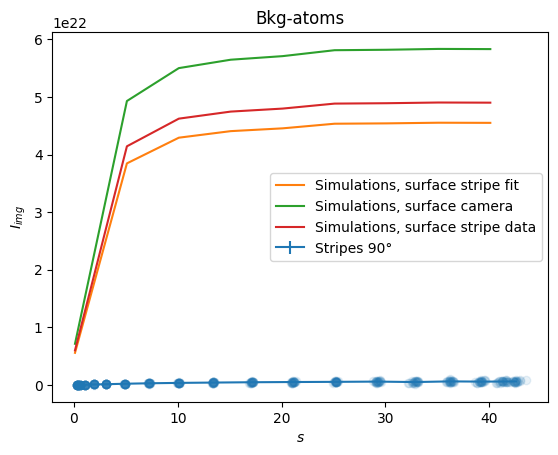

In [62]:
close("all")
fig = subplots()
title("Bkg-atoms")


# Stripes 90°
line_stripe_90, = errorbar(factor_sat * Mean_bkg/Isat, Mean_bkg_atoms*S_stripe_data/S_img, yerr=Std_bkg_atoms, label="Stripes 90°")

for i = 1:size(Iatoms_img)[1]
    for j = 1:size(Iatoms_img)[2]
        scatter(factor_sat * Ibkg_img[i, j]/Isat, (Ibkg_img[i, j]-Iatoms_img[i, j])*S_stripe_data/S_img, color=line_stripe_90.get_color(), alpha = 0.1)
    end
end


# # Simulations
factor_sim_data = (1-0.16) # Amount of light that will not enter in the camera
@load "Solutions_sim/Itot_N_30_Sat_0.1to40.1_n0_53.12_decay_rate_up_down.jdl2" sat sat_computed n_list Itot_stripe I_SE_SR_SS_stripe I_SR_SR_SS_stripe nbr_error_N
# S_img = size(Imgs_atoms_crop_ds)[1]*size(Imgs_atoms_crop_ds)[2]*size_pxl^2
# S_stripe = π * 7.630504388680256e-6 * 1.5864096721914764e-6
# S_stripe_data = π*mean(major_axis_list)*mean(minor_axis_list)*(size_pxl/factor_ellipse)^2

plot(sat_computed, factor_sim_data * Itot_stripe * Ntot / (N*length(n_list)*S_stripe*mean(nbr_stripes_ds[nbr_stripes_ds.>0])), label="Simulations, surface stripe fit")
plot(sat_computed, factor_sim_data * Itot_stripe * Ntot / (N*length(n_list)*S_img*mean(nbr_stripes_ds[nbr_stripes_ds.>0])), label="Simulations, surface camera")
plot(sat_computed, factor_sim_data * Itot_stripe * Ntot / (N*length(n_list)*S_stripe_data*mean(nbr_stripes_ds[nbr_stripes_ds.>0])), label="Simulations, surface stripe data")

# for i = 1:size(I_sim)[1]
#     for j = 1:size(I_sim)[2]
#         scatter(factor_sat * Ibkg_stripe_90[i+idx_lb-1, j]/Isat, I_sim[i, j], color=line_sim.get_color(), alpha = 0.1)
#     end
# end


xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

### Fit the surface

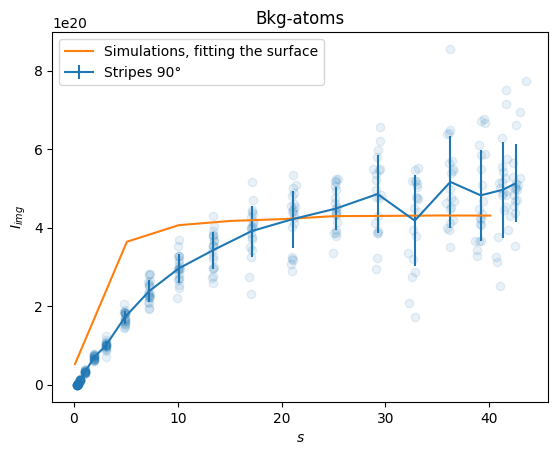

In [63]:
close("all")
fig = subplots()
title("Bkg-atoms")


# Stripes 90°
line_stripe_90, = errorbar(factor_sat * Mean_bkg/Isat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Stripes 90°")

for i = 1:size(Iatoms_img)[1]
    for j = 1:size(Iatoms_img)[2]
        scatter(factor_sat * Ibkg_img[i, j]/Isat, (Ibkg_img[i, j]-Iatoms_img[i, j]), color=line_stripe_90.get_color(), alpha = 0.1)
    end
end


# # Simulations
# S_img = size(Imgs_atoms_crop_ds)[1]*size(Imgs_atoms_crop_ds)[2]*size_pxl^2
# S_stripe = π * 7.630504388680256e-6 * 1.5864096721914764e-6
# S_stripe_data = π*mean(major_axis_list)*mean(minor_axis_list)*(size_pxl/factor_ellipse)^2

I_sim_norm = Itot_stripe # .* Ntot / (N*length(n_list)*mean(nbr_stripes_ds[nbr_stripes_ds.>0]))

factor_sim_data_fit = (1-0.16) *Mean_bkg_atoms[end]/I_sim_norm[end] # Amount of light that will not enter in the camera

plot(sat_computed, factor_sim_data_fit * I_sim_norm, label="Simulations, fitting the surface")

# for i = 1:size(I_sim)[1]
#     for j = 1:size(I_sim)[2]
#         scatter(factor_sat * Ibkg_stripe_90[i+idx_lb-1, j]/Isat, I_sim[i, j], color=line_sim.get_color(), alpha = 0.1)
#     end
# end


xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

### Add SE

In [59]:
function decay_atoms_indep_V3(sat)
    return 1/2 .* 1 ./ (1 .+ 1 ./sat)
end

decay_atoms_indep_V3 (generic function with 1 method)

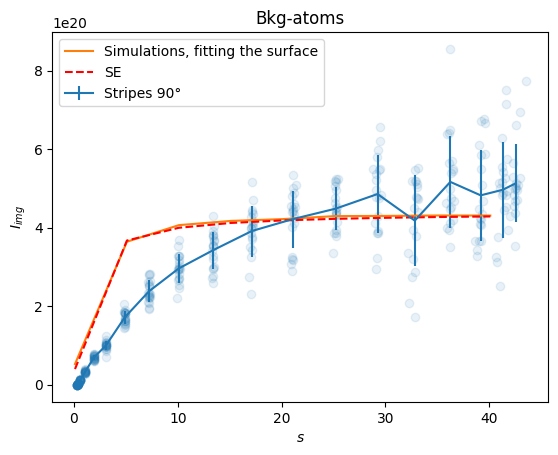

In [64]:
close("all")
fig = subplots()
title("Bkg-atoms")


# Stripes 90°
line_stripe_90, = errorbar(factor_sat * Mean_bkg/Isat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Stripes 90°")

for i = 1:size(Iatoms_img)[1]
    for j = 1:size(Iatoms_img)[2]
        scatter(factor_sat * Ibkg_img[i, j]/Isat, (Ibkg_img[i, j]-Iatoms_img[i, j]), color=line_stripe_90.get_color(), alpha = 0.1)
    end
end



plot(sat_computed, factor_sim_data_fit * I_sim_norm, label="Simulations, fitting the surface")



# SE .* Ntot / (N*length(n_list)*mean(nbr_stripes_ds[nbr_stripes_ds.>0]))
line_SE, = plot(sat_computed, factor_sim_data_fit * decay_atoms_indep_V3(sat_computed) * γ * N * length(n_list), label="SE", color="r", linestyle="--")


xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

### Add higher densities

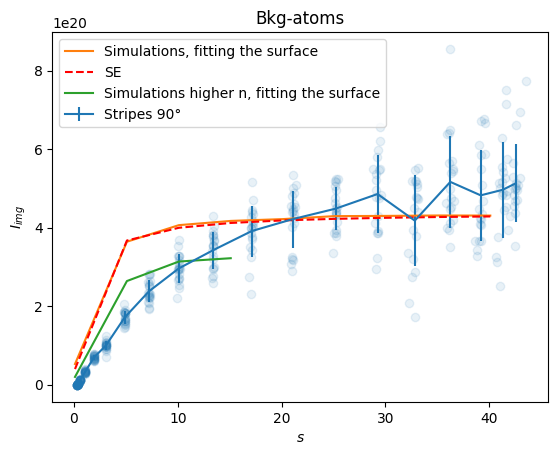

In [65]:
close("all")
fig = subplots()
title("Bkg-atoms")


# Stripes 90°
line_stripe_90, = errorbar(factor_sat * Mean_bkg/Isat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Stripes 90°")

for i = 1:size(Iatoms_img)[1]
    for j = 1:size(Iatoms_img)[2]
        scatter(factor_sat * Ibkg_img[i, j]/Isat, (Ibkg_img[i, j]-Iatoms_img[i, j]), color=line_stripe_90.get_color(), alpha = 0.1)
    end
end



plot(sat_computed, factor_sim_data_fit * I_sim_norm, label="Simulations, fitting the surface")



# SE .* Ntot / (N*length(n_list)*mean(nbr_stripes_ds[nbr_stripes_ds.>0]))
line_SE, = plot(sat_computed, factor_sim_data_fit * decay_atoms_indep_V3(sat_computed) * γ * N * length(n_list), label="SE", color="r", linestyle="--")


@load "Solutions_sim/Itot_N_30_Sat_0.1to40.1_n0_531.24_decay_rate_up_down.jdl2" sat sat_computed n_list Itot_stripe I_SE_SR_SS_stripe I_SR_SR_SS_stripe nbr_error_N
plot(sat_computed, factor_sim_data_fit * Itot_stripe, label="Simulations higher n, fitting the surface")


xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

### Select stipe with a lot of atoms

In [ ]:
for i in 1:size(Iatoms_stripe_90)[1]
    for j in 1:size(Iatoms_stripe_90)[2]
        for k in 1:Int(nbr_stripes_ds[i, j])
            scatter(factor_sat * Ibkg_stripe_90[i, j]/Isat, Nbr_atoms_per_stripe[i, j, k], color="b")
        end
    end
end

Nbr_atoms_boundary_lb = 1e3
Sat_atoms_boundary_lb = 3

axhline(Nbr_atoms_boundary_lb, color="r")
axvline(Sat_atoms_boundary_lb, color="r")

xlabel(L"Idx of $I_{laser}$")
ylabel(L"s")

In [ ]:
# Compute the simulated intensity for each image
idx_lb_atom_nbr = 6
I_sim_select = zeros((idx_hb-idx_lb_atom_nbr+1, size(Ibkg_stripes)[2]))

for i = idx_lb_atom_nbr:idx_hb
    for j = 1:size(Ibkg_stripes)[2]
        if nbr_stripes_ds[i, j] > 0
            for k in 1:Int(nbr_stripes_ds[i, j])
                if Nbr_atoms_per_stripe[i, j, k] > Nbr_atoms_boundary_lb
                    S_stripe = π * (major_axis_stripes_ds[i][j][k]/factor_ellipse) * (minor_axis_stripes_ds[i][j][k]/factor_ellipse) * size_pxl^2
                    if S_stripe > 0
                        I_sim_select[i-idx_lb_atom_nbr+1, j] += (Nbr_atoms_per_stripe[i, j, k]/(N*length(n_list)*S_stripe)) * interp_linear_sim(factor_sat * Ibkg_stripe_90[i, j]/Isat)
                    end
                end
            end
        end
    end
end

In [ ]:

### Plot as a function of Sat measured from the images bkg
close("all")
fig = subplots()
title("Bkg-atoms")


# Stripes 90°
line_stripe_90, = errorbar(factor_sat * Mean_bkg_stripe_90/Isat, Mean_bkg_atoms_stripe_90, yerr=Std_bkg_atoms_stripe_90, label="Stripes 90°")

for i = 1:size(Iatoms_stripe_90)[1]
    for j = 1:size(Iatoms_stripe_90)[2]
        scatter(factor_sat * Ibkg_stripe_90[i, j]/Isat, Ibkg_stripe_90[i, j]-Iatoms_stripe_90[i, j], color=line_stripe_90.get_color(), alpha = 0.1)
    end
end


# # Simulations
factor_sim_data = (1-0.16) # Amount of light that will not enter in the camera
line_sim, = errorbar(factor_sat * Mean_bkg_stripe_90[idx_lb_atom_nbr:idx_hb]/Isat, reshape(factor_sim_data * mean(I_sim_select, dims=2), size(I_sim_select)[1]), yerr=reshape(factor_sim_data * std(I_sim_select, dims=2), size(I_sim_select)[1]), label="simulations")

for i = 1:size(I_sim_select)[1]
    for j = 1:size(I_sim_select)[2]
        scatter(factor_sat * Ibkg_stripe_90[i+idx_lb_atom_nbr-1, j]/Isat, I_sim_select[i, j], color=line_sim.get_color(), alpha = 0.1)
    end
end


xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

# Brouillons

In [ ]:
i, j, k = 5, 2, 1
@load "Saved_exp_data/ODs_crop_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" ODs_dataset

close("all")
fig, axes = subplots(1, 3, figsize=(15, 5))

OD = ODs_dataset[i, j, :, :]

OD = Ntot/sum(OD .- minimum(OD)) .* (OD .- minimum(OD)) # Transform the OD in atom/pxl^2

OD_rot = find_rotate_angle_stripes(OD)[1]

axes[1].imshow(OD_rot)
mask = mask_ellipse(centers_stripes_ds[i][j][k][1], centers_stripes_ds[i][j][k][2], major_axis_stripes_ds[i][j][k]/factor_ellipse, minor_axis_stripes_ds[i][j][k]/factor_ellipse, 0, size(OD_rot)[1], size(OD_rot)[2])
axes[2].imshow(mask)
axes[3].imshow(mask .* OD_rot)

println("Nbr of atoms in this stripe = $(sum(mask .* OD_rot))")

for ax in axes
    ax.axis("off")
end

pygui(false)

In [ ]:
using Images, ImageFiltering, Rotations, ImageTransformations, CoordinateTransformations

function rotate_img_stripe_angle(img)
    """ Finds the angle at which the stripes are along the horizontal axis,
    ie where a sum along the horizontal axis is maximal """
    θ_range = [0:0.1:π/2;]

    Maximum_hor_mean = zeros(length(θ_range))

    for (i, θ) in enumerate(θ_range)
        imgw = rot_img(img, θ)

        Maximum_hor_mean[i] = maximum(sum(imgw, dims=2))
    end
    return θ_range[argmax(Maximum_hor_mean)]
end

function rot_img(img, θ)
    """ Rotate an image with an angle θ, padd with 0 """
    trfm = recenter(RotMatrix(θ), center(img))
    imgw = parent(warp(img, trfm))
    imgw[isnan.(imgw)] .= 0 # Padd the NaN values to 0
    return imgw
end

function find_rotate_angle_stripes(img)
    """ Find the angle of the stripes and return the image rotated by this angle 
    so that the stripes are along the horizontal axis, and the angle as a 2nd argument """
    θ = rotate_img_stripe_angle(img)
    return rot_img(img, θ), θ
end

function mask_ellipse(xc, yc, a, b, θ, width, height)
    """ Mask of size (width, height) of an ellipse rotated by an angle θ, centered on [xc, yc], with HALF major/minor axis a/b"""
    mask = zeros(Integer, (width, height))
    X = range(0, height-1) .- yc
    Y = range(0, width-1) .- xc
    for (i, x) in enumerate(X)
        for (j, y) in enumerate(Y)
            # Rotate back
            x_hor = x*sin(θ) + y*cos(θ)
            y_hor = x*cos(θ) - y*sin(θ)
            
            if (x_hor/a)^2 + (y_hor/b)^2 ≤ 1
                mask[i, j] = 1
            end
        end
    end
    return mask
end

In [ ]:
factor_sat * Mean_bkg_stripe_90[idx_lb:idx_hb]/Isat

In [ ]:
I_sim

In [ ]:
plot(I_sim)